# Smart LogiTrack - Système Prédictif de Transport Urbain (ETA)

### The Process

* `Ingest` Read the file (Parquet/CSV).

* `Clean` Handle Nulls, filter outliers.

* `Feature Eng` Create new variables.

* `Split` Separate Train / Test.

* `Train` model.fit()

* `Evaluate` Compare the prediction to reality.

## pyspark's test

In [1]:
""" from pyspark.sql import SparkSession
import sys

# 1. Initialize Spark (Spark 4.x style)
spark = SparkSession.builder \
    .appName("DistutilsCheck") \
    .getOrCreate()

# 2. Print versions to verify context
print(f"python version: {sys.version}")
print(f"spark version: {spark.version}")

# 3. Create a simple DataFrame (triggers the internal worker setup)
data = [("LogiTrack", 1), ("Test", 2)]
df = spark.createDataFrame(data, ["Project", "ID"])

df.show()
print("✅ If you see the table above, distutils is NOT an issue!") """

' from pyspark.sql import SparkSession\nimport sys\n\n# 1. Initialize Spark (Spark 4.x style)\nspark = SparkSession.builder     .appName("DistutilsCheck")     .getOrCreate()\n\n# 2. Print versions to verify context\nprint(f"python version: {sys.version}")\nprint(f"spark version: {spark.version}")\n\n# 3. Create a simple DataFrame (triggers the internal worker setup)\ndata = [("LogiTrack", 1), ("Test", 2)]\ndf = spark.createDataFrame(data, ["Project", "ID"])\n\ndf.show()\nprint("✅ If you see the table above, distutils is NOT an issue!") '

In [2]:
# from pyspark.sql import SparkSession

# # Stop the old session first
# my_spark.stop()

# # Start a new session with 4GB of RAM
# spark = SparkSession.builder \
#     .appName("TaxiDurationPrediction") \
#     .config("spark.driver.memory", "4g") \
#     .config("spark.executor.memory", "4g") \
#     .getOrCreate()

# print("Spark Session restarted with 4GB RAM!")

## Bronze layer
### Data Loading 

In [3]:
from pyspark.sql import SparkSession

# --- session config 
my_spark=SparkSession.builder.appName("Smart-Logistic").config("spark.driver.memory", "4g").config("spark.executor.memory", "4g").getOrCreate()
print(my_spark)

# --- loading data
df_path="../data/bronze_taxi.parquet"
df_bronze=my_spark.read.parquet(df_path)
df_bronze.show(5)
print("_________________________")
shape=(df_bronze.count(), len(df_bronze.columns))
print(f"shape (lines, cols) : {shape}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/19 01:36:09 WARN Utils: Your hostname, MAE, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/01/19 01:36:09 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/19 01:36:11 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|       1| 2025-01-01 00:18:38|  2025-01-01 00:26:59|              1|          1.6|         1|                 N|         229|    

In [4]:
print("=== schema ===")
df_bronze.printSchema()

=== schema ===
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)



In [5]:
# --- pyspark : select obj col
print(" === obj col ===")
str_col=[c for c,t in df_bronze.dtypes if t.startswith('string')]
df_obj=df_bronze.select(str_col).show(3)
print(f"string col : {str_col}")

# --- possible val : obj col
print(f" === possible val of {df_obj} === ")
df_bronze.select('store_and_fwd_flag').distinct().show()
# df_obj=df_bronze.select_dtypes(['object'])
# df_obj.head(100)
# df_bronze['store_and_fwd_flag'].unique()

 === obj col ===
+------------------+
|store_and_fwd_flag|
+------------------+
|                 N|
|                 N|
|                 N|
+------------------+
only showing top 3 rows
string col : ['store_and_fwd_flag']
 === possible val of None === 


+------------------+
|store_and_fwd_flag|
+------------------+
|                 Y|
|                 N|
|              NULL|
+------------------+



## Silver layer
### Target creation

In [6]:
from pyspark.sql.functions import col, unix_timestamp, hour, dayofweek, month

# tpep_pickup_datetime, tpep_dropoff_datetime: timestamp_ntz (nullable = true)
df_bronze_target=df_bronze.withColumn(
    "duration_seconds", 
    unix_timestamp(col("tpep_dropoff_datetime")) - unix_timestamp(col("tpep_pickup_datetime"))
)

df_silver=df_bronze_target.withColumn(
    "duration_minutes",
    col("duration_seconds") / 60
)
df_silver.select("tpep_pickup_datetime", "tpep_dropoff_datetime", "duration_minutes")

DataFrame[tpep_pickup_datetime: timestamp_ntz, tpep_dropoff_datetime: timestamp_ntz, duration_minutes: double]

## resolve NULL values

In [7]:
# from pyspark.sql.functions import col
# for cols in df_final: 
#     df_final=df_final.fillna(-1, subset=cols)



In [8]:
# --- col : payment_type
df_silver=df_silver.fillna(-1, subset=["payment_type"])

# --- store_and_fwd_flag
df_silver=df_silver.fillna(-1, subset=["store_and_fwd_flag"])

### Categorical var

In [9]:
from pyspark.ml.feature import StringIndexer

# --- possible val 
df_bronze.groupBy("store_and_fwd_flag").count().show()

# --- encode cat variable
index=StringIndexer(inputCol="store_and_fwd_flag", outputCol="store_and_fwd_flag_encoded", handleInvalid="keep")
df_encoded=index.fit(df_silver).transform(df_silver)

# -> checking
df_encoded.select("store_and_fwd_flag","store_and_fwd_flag_encoded")

+------------------+-------+
|store_and_fwd_flag|  count|
+------------------+-------+
|                 Y|   7646|
|                 N|2927431|
|              NULL| 540149|
+------------------+-------+



DataFrame[store_and_fwd_flag: string, store_and_fwd_flag_encoded: double]

### Correlation

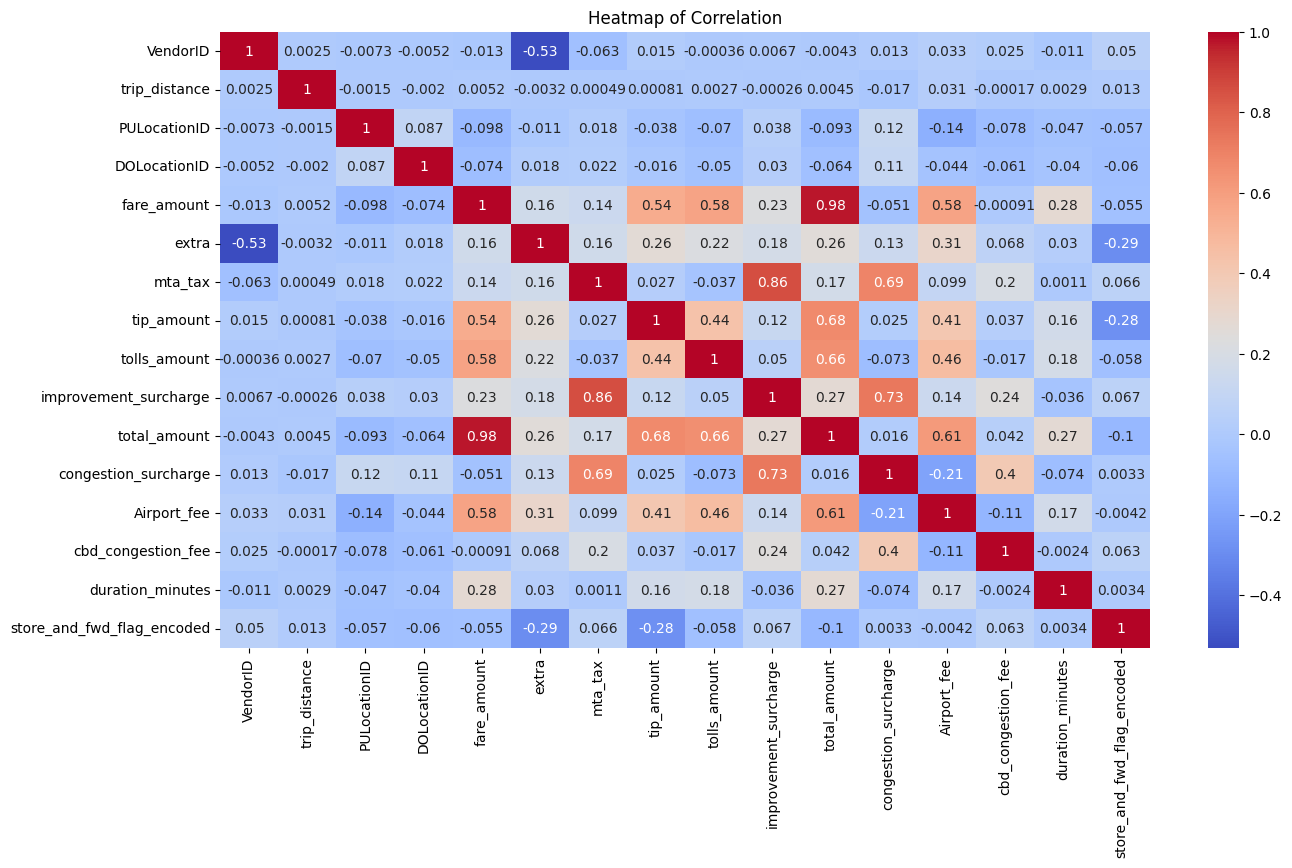

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- select : num col
num_types=["int", "float", "double", "long"]
num_col= [c for c,t in df_encoded.dtypes if t in num_types]
df_numeric = df_encoded.select(num_col)  # df : only num

# --- heatmap
pdf_num=df_numeric.sample(fraction=0.1, seed=42).toPandas()
corr_matrix=pdf_num.corr()      # correlation Calcul

# --- graph
# for col in df_numeric:
plt.figure(figsize=(15,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Heatmap of Correlation")         
plt.show()


### Cleaning & Feature Engineering : Silver

In [11]:
# import datetime
df_encoded=df_encoded.filter(
    # -> Distance ≤ 0 ou > 200 miles
    (col("trip_distance")> 0) & (col("trip_distance") <= 200) &  

    # -> Durée ≤ 0 minutes      
    (col("duration_minutes") > 0) & (col("duration_minutes") < 300) &       # outlier : (>5h)
    
    # -> Passagers ≤ 0
    (col("passenger_count") > 0)
)   

# --- add time features
df_encoded=df_encoded.withColumn("pickup_hour", hour("tpep_pickup_datetime")) \
                .withColumn("day_of_week", dayofweek("tpep_pickup_datetime")) \
                .withColumn("month", month("tpep_pickup_datetime"))

df_encoded.select("tpep_pickup_datetime", "duration_minutes", "trip_distance", "pickup_hour", "day_of_week", "month").show(5)

+--------------------+-----------------+-------------+-----------+-----------+-----+
|tpep_pickup_datetime| duration_minutes|trip_distance|pickup_hour|day_of_week|month|
+--------------------+-----------------+-------------+-----------+-----------+-----+
| 2025-01-01 00:18:38|             8.35|          1.6|          0|          4|    1|
| 2025-01-01 00:32:40|             2.55|          0.5|          0|          4|    1|
| 2025-01-01 00:44:04|             1.95|          0.6|          0|          4|    1|
| 2025-01-01 00:14:27|5.566666666666666|         0.52|          0|          4|    1|
| 2025-01-01 00:21:34|3.533333333333333|         0.66|          0|          4|    1|
+--------------------+-----------------+-------------+-----------+-----------+-----+
only showing top 5 rows


## EDA - visualization

In [12]:
# -> take a sample 
pdf_sample=df_encoded.sample(fraction=0.1, seed=42).toPandas()

26/01/19 01:36:45 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [13]:
# df_silver.columns

### scatterplot - The Relationship Check

/tmp/ipykernel_17332/1741081314.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(15,8))


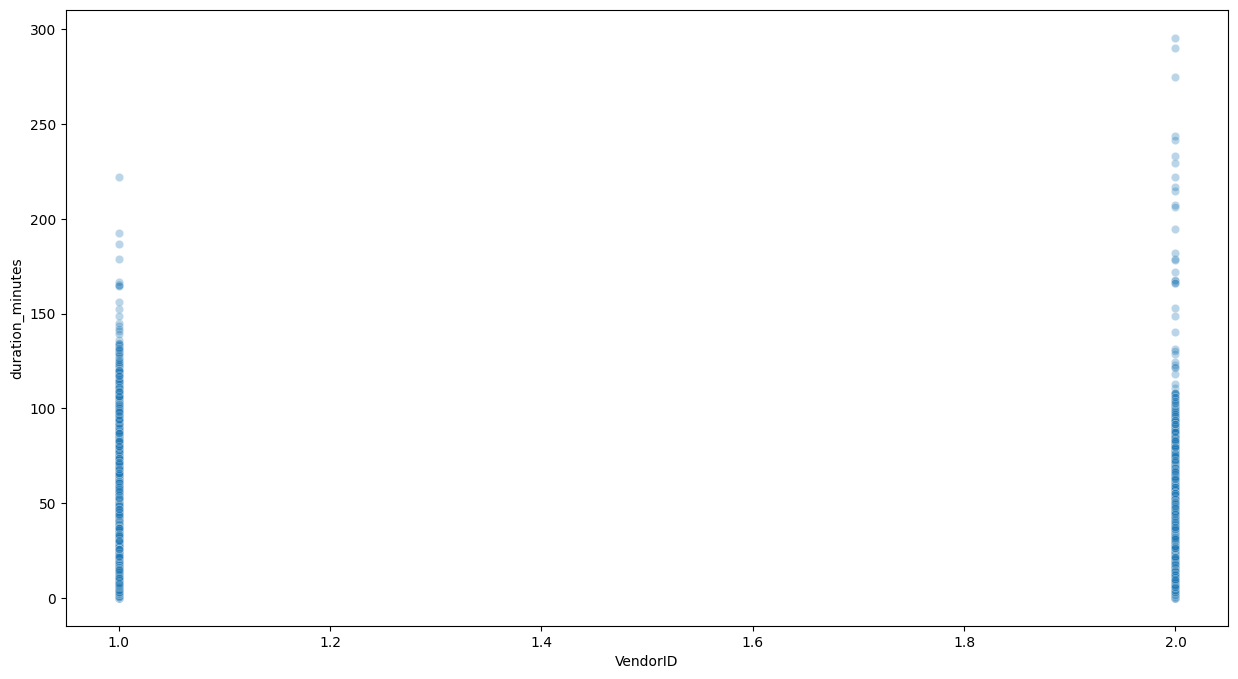

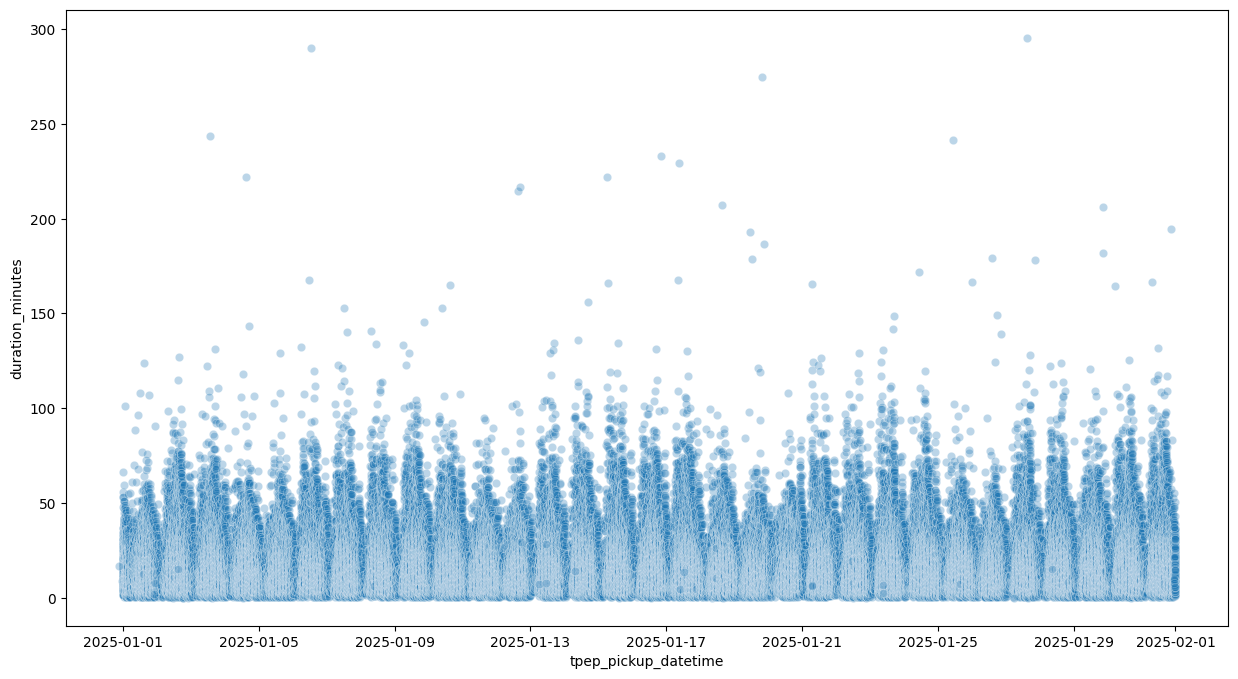

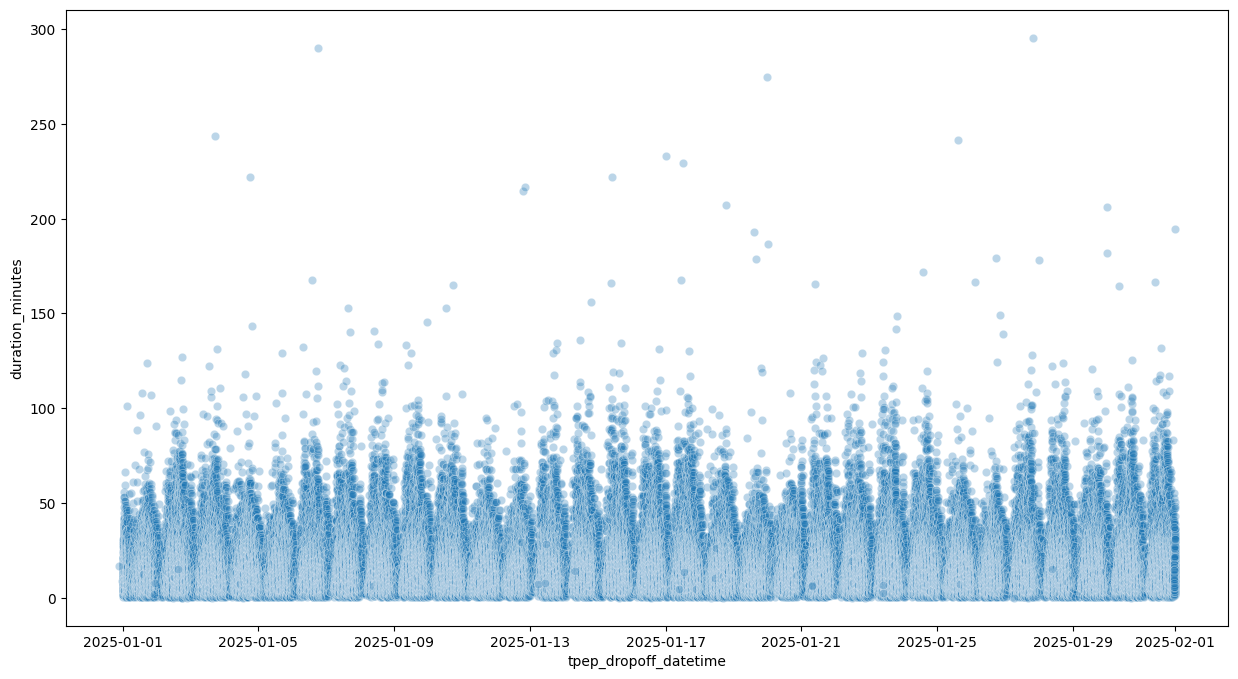

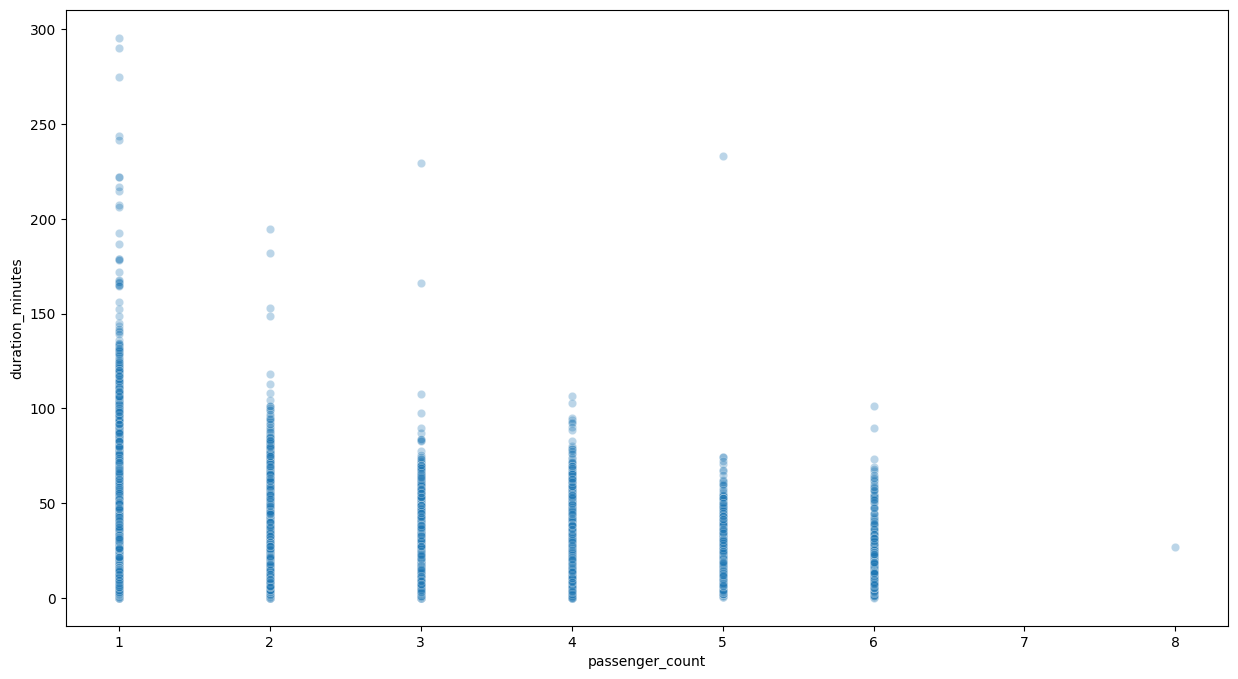

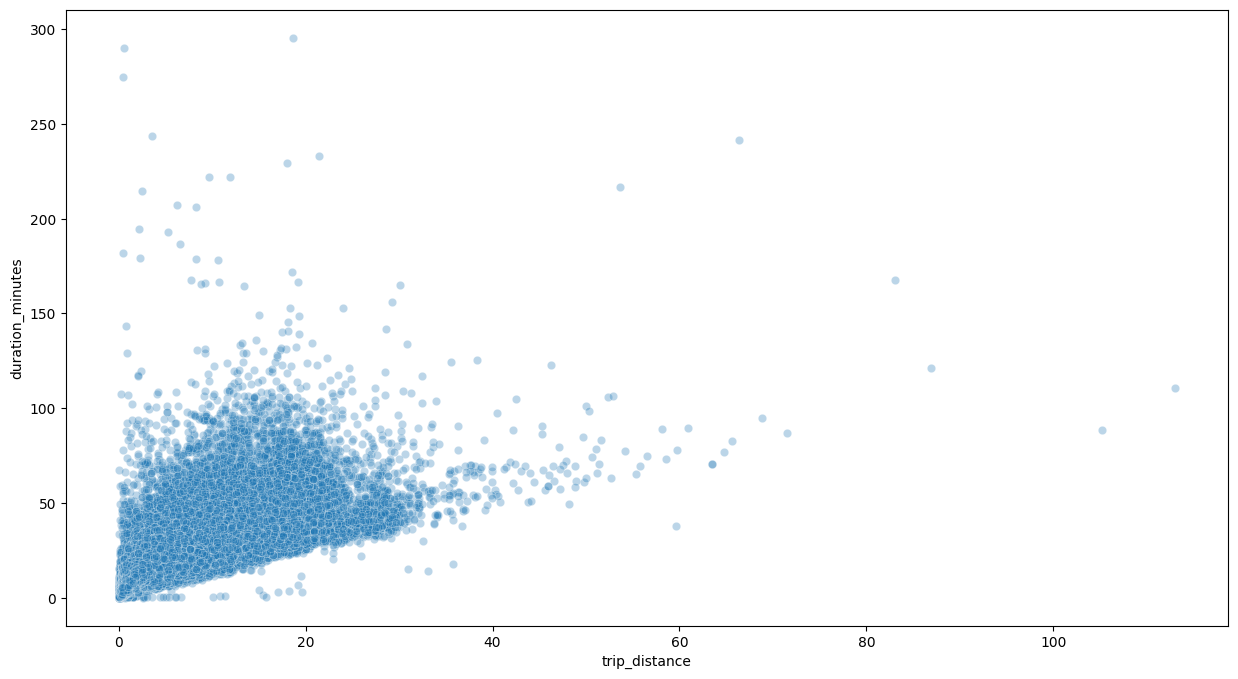

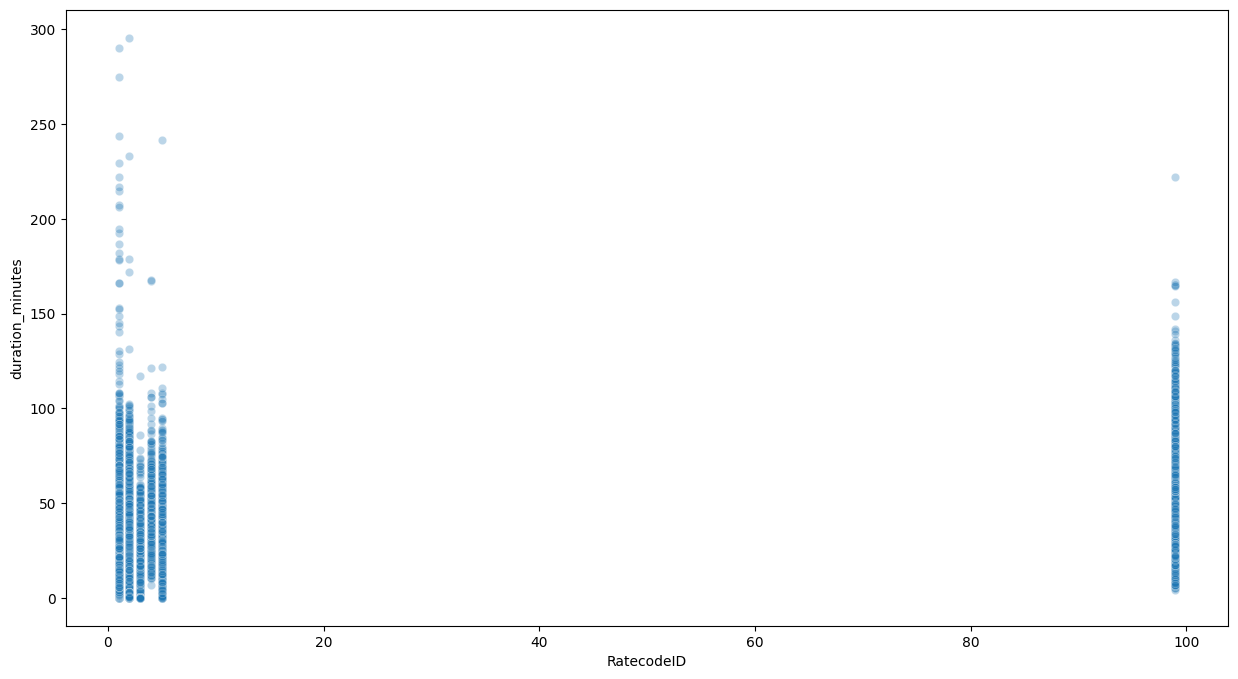

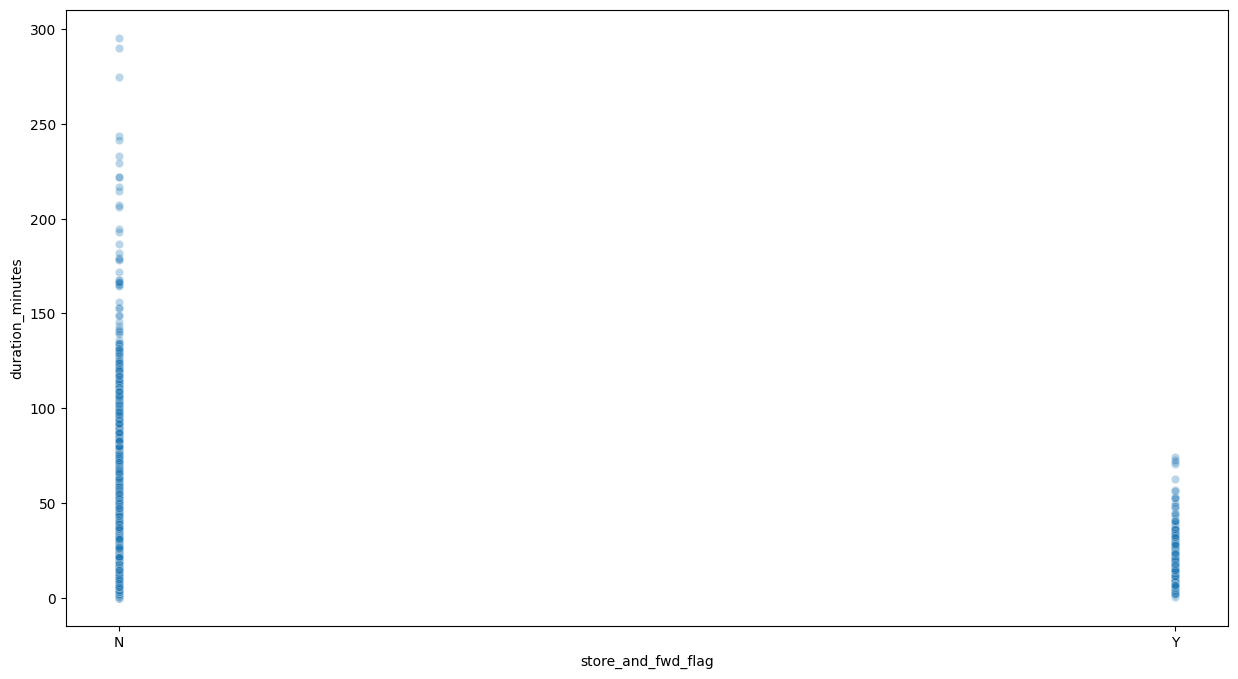

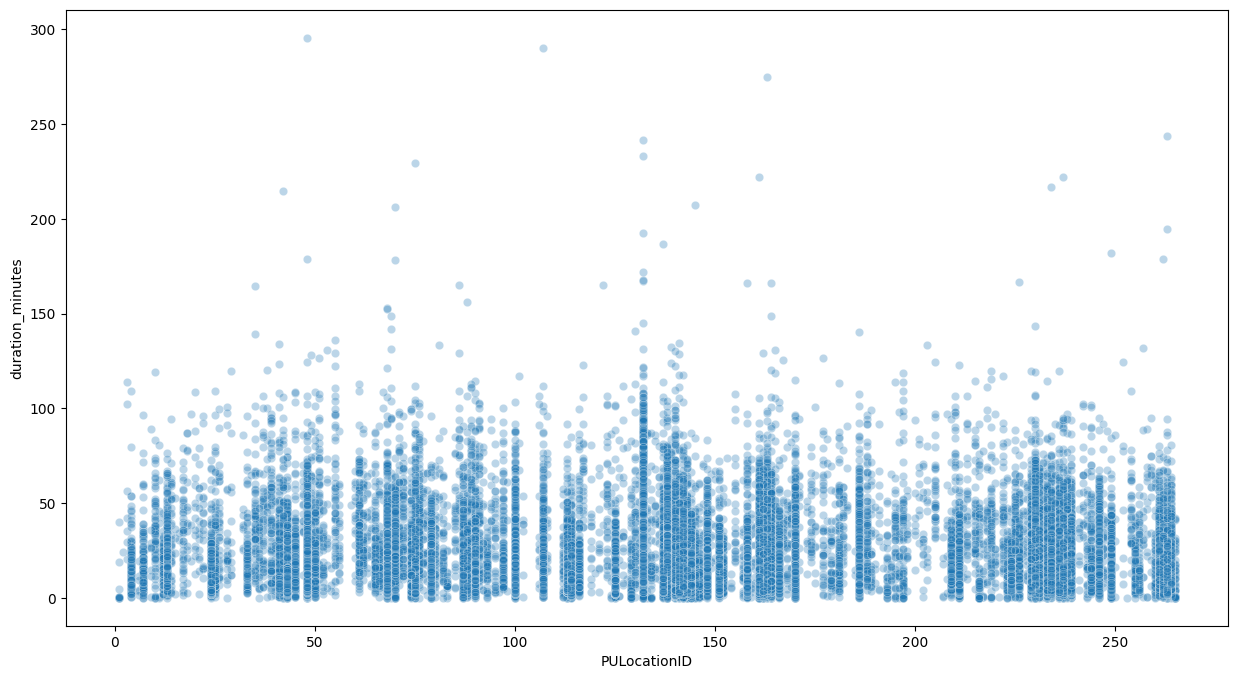

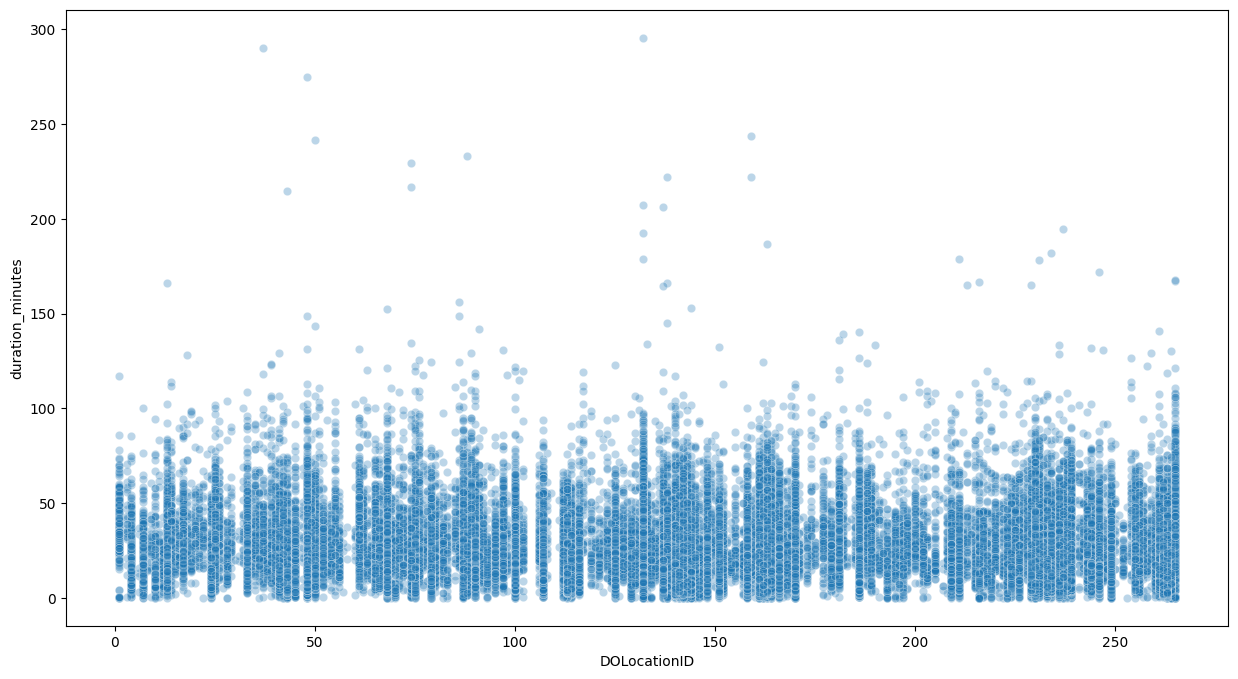

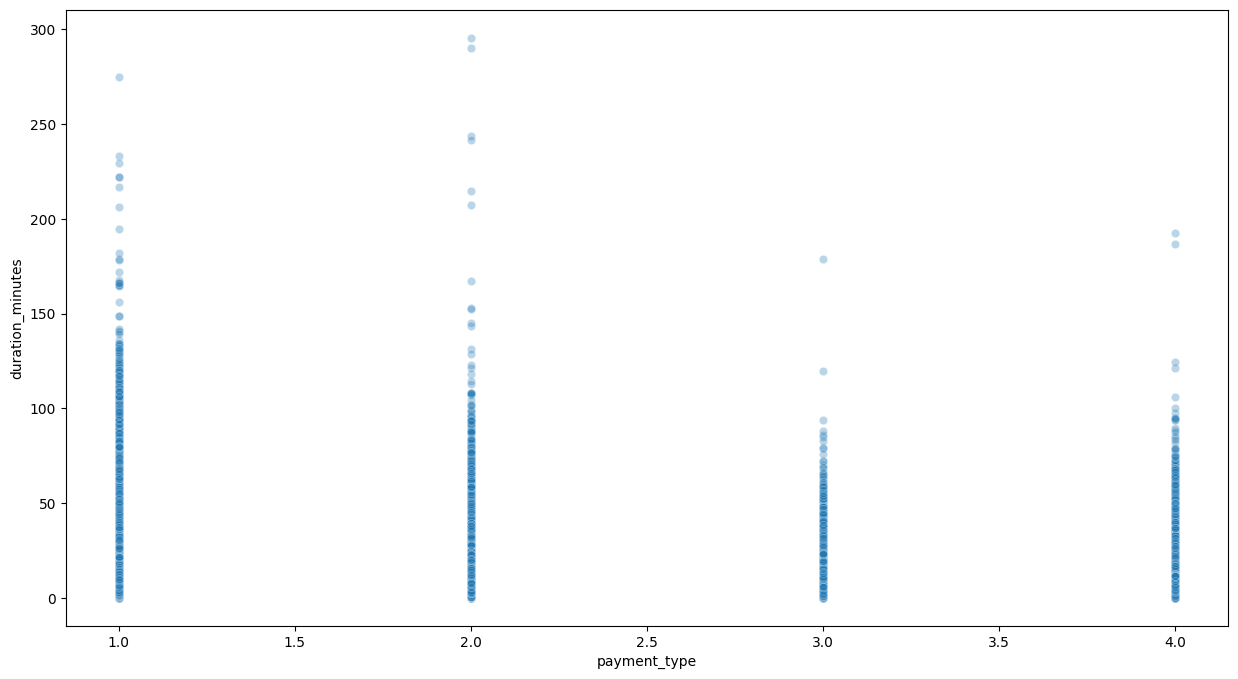

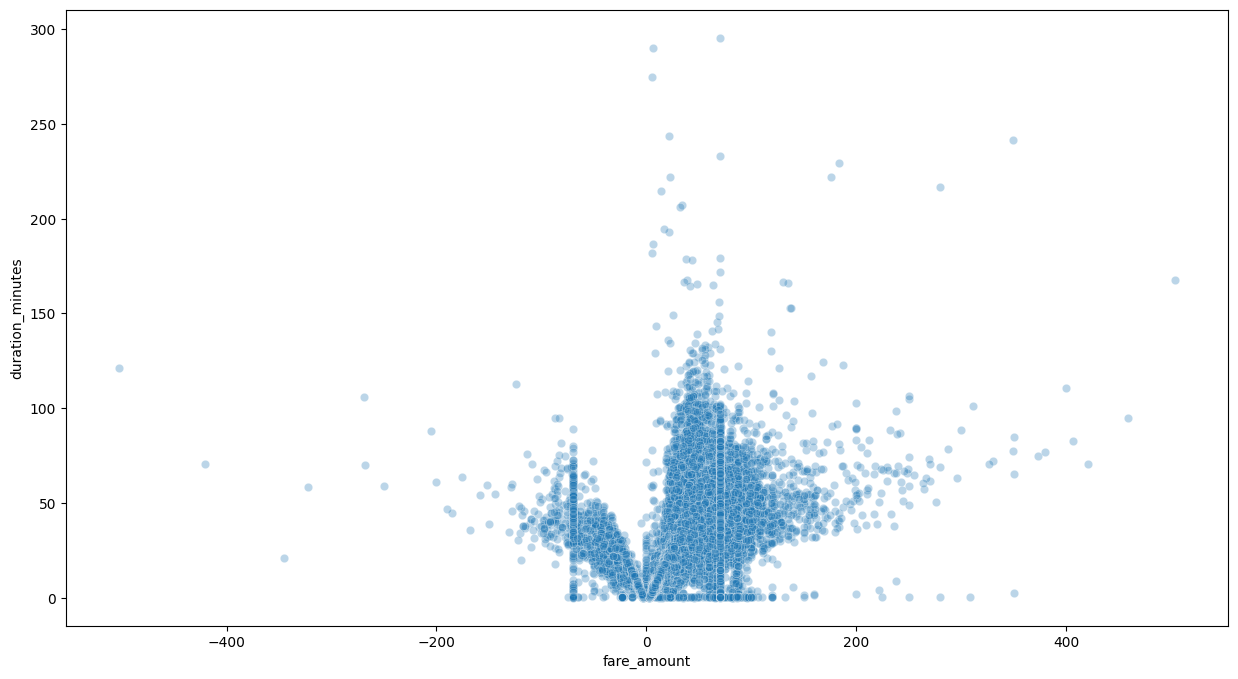

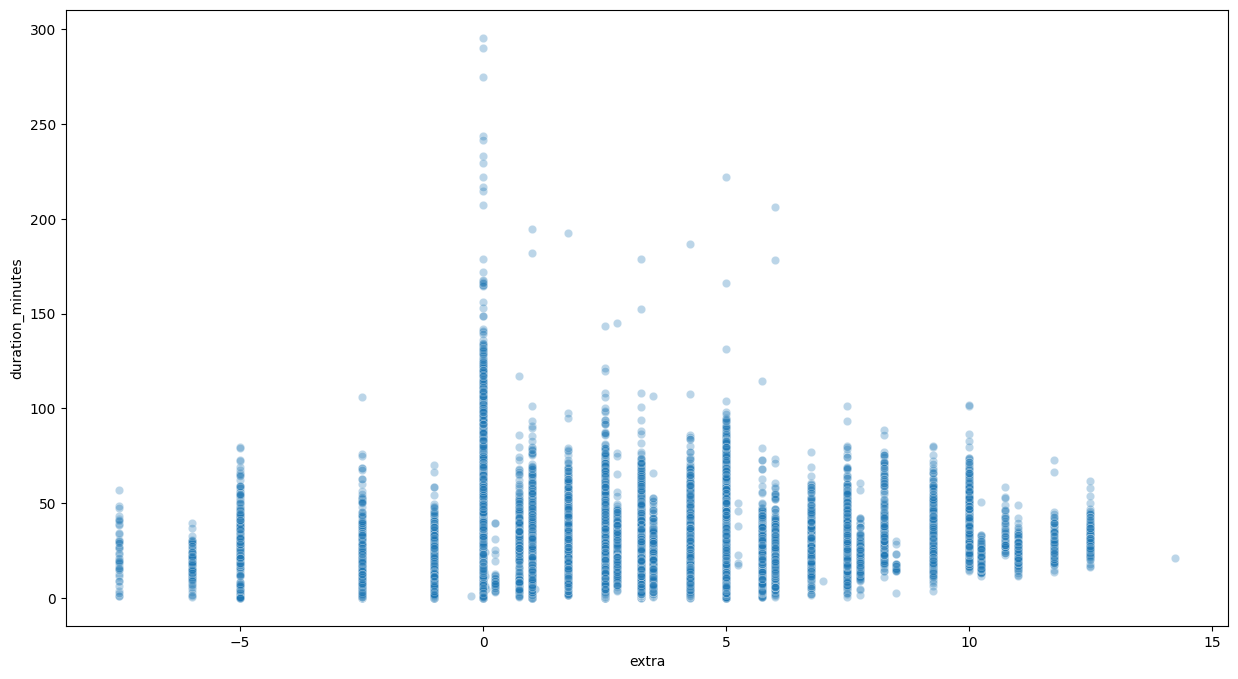

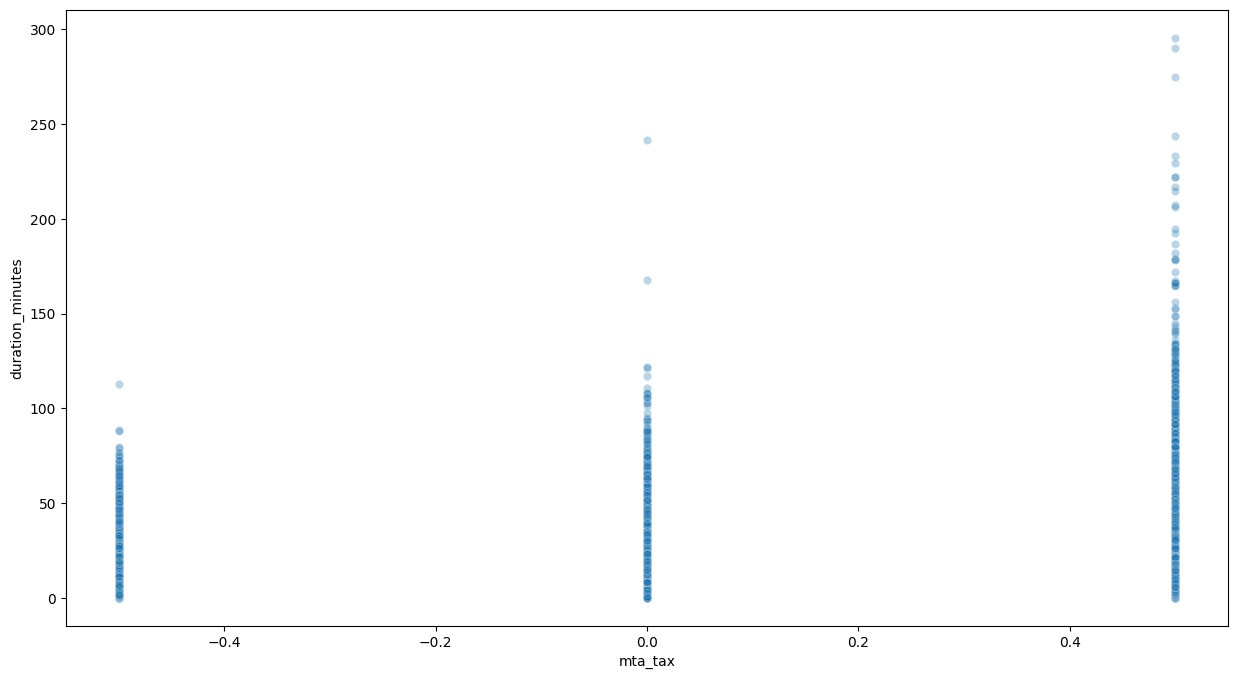

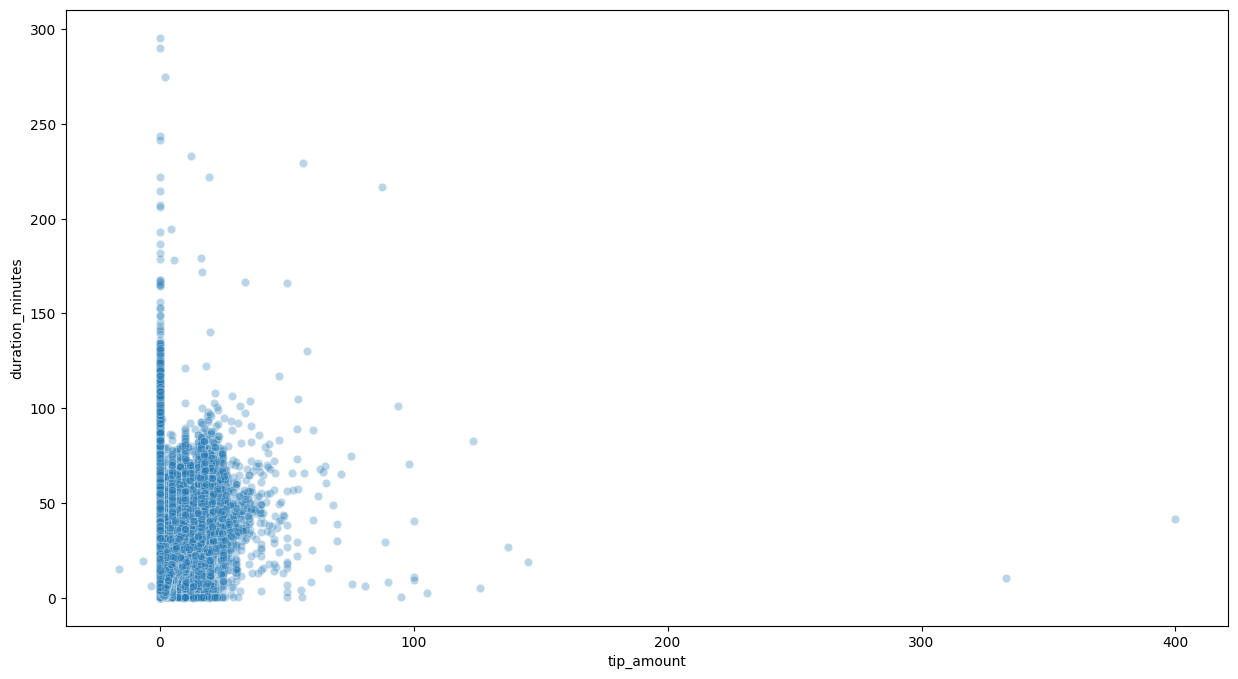

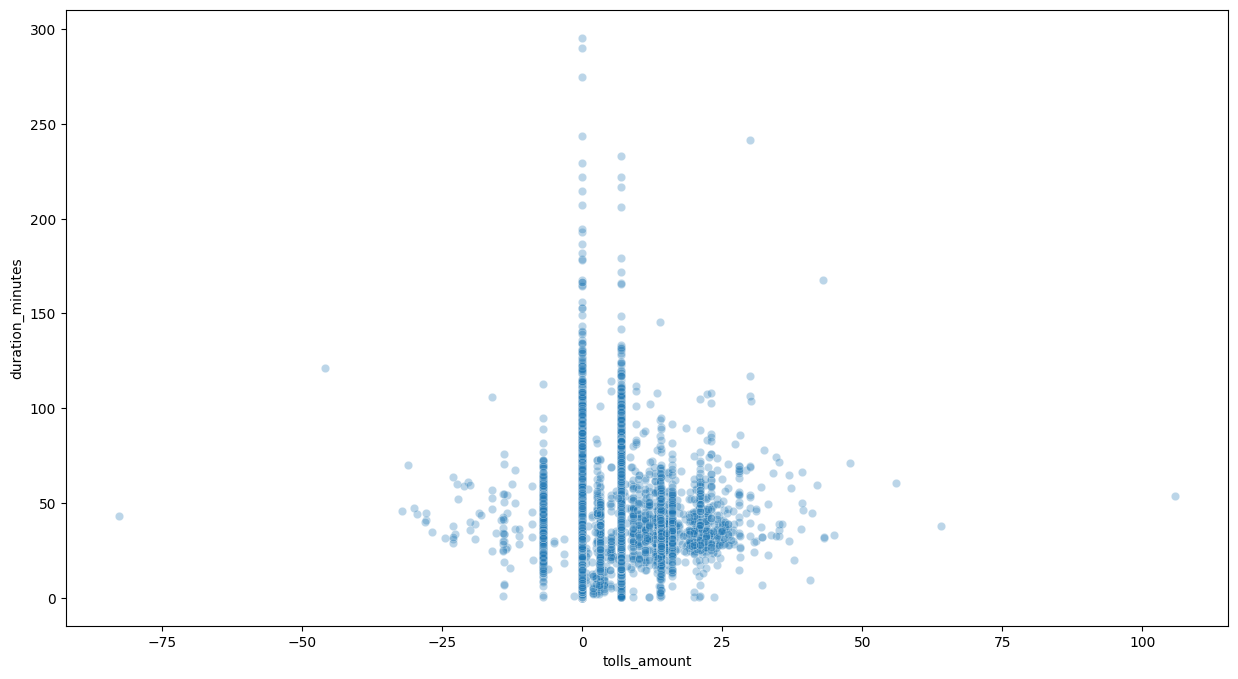

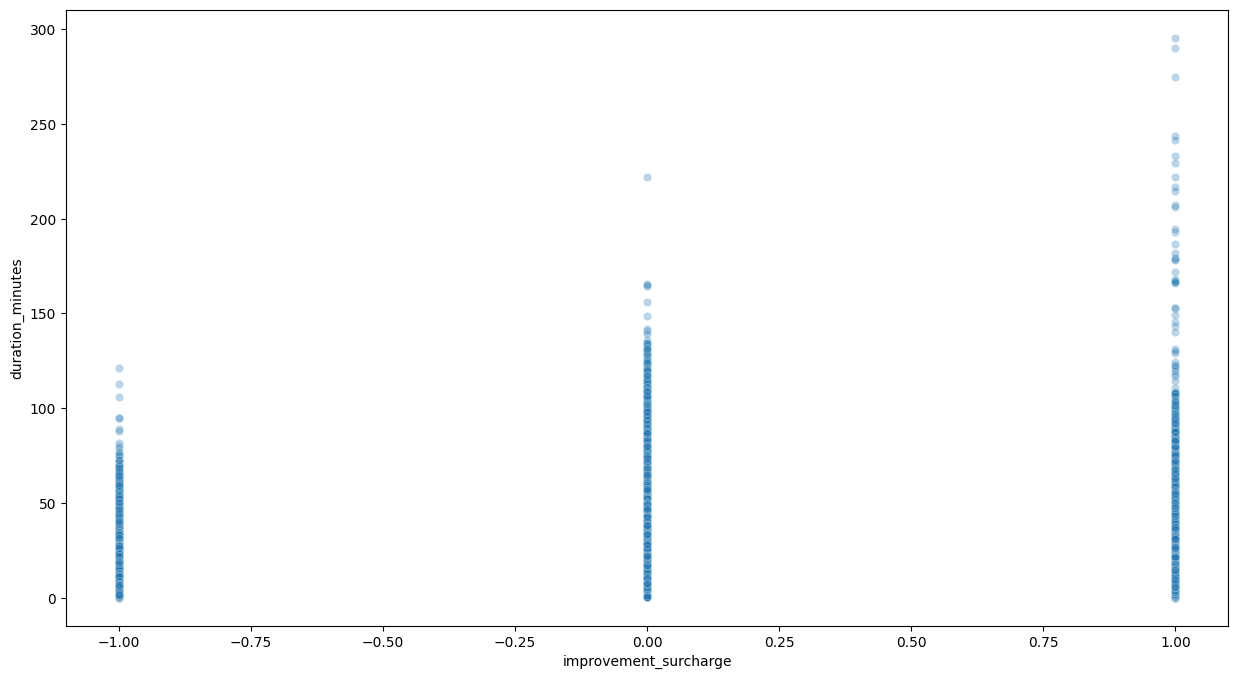

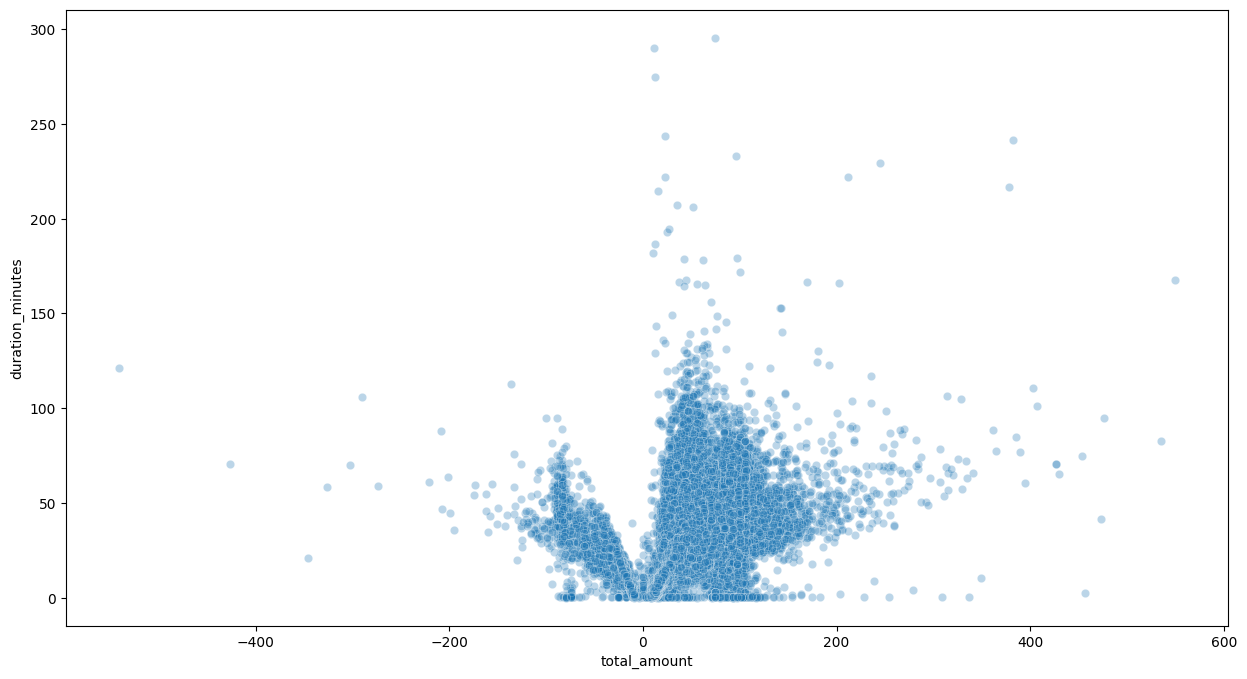

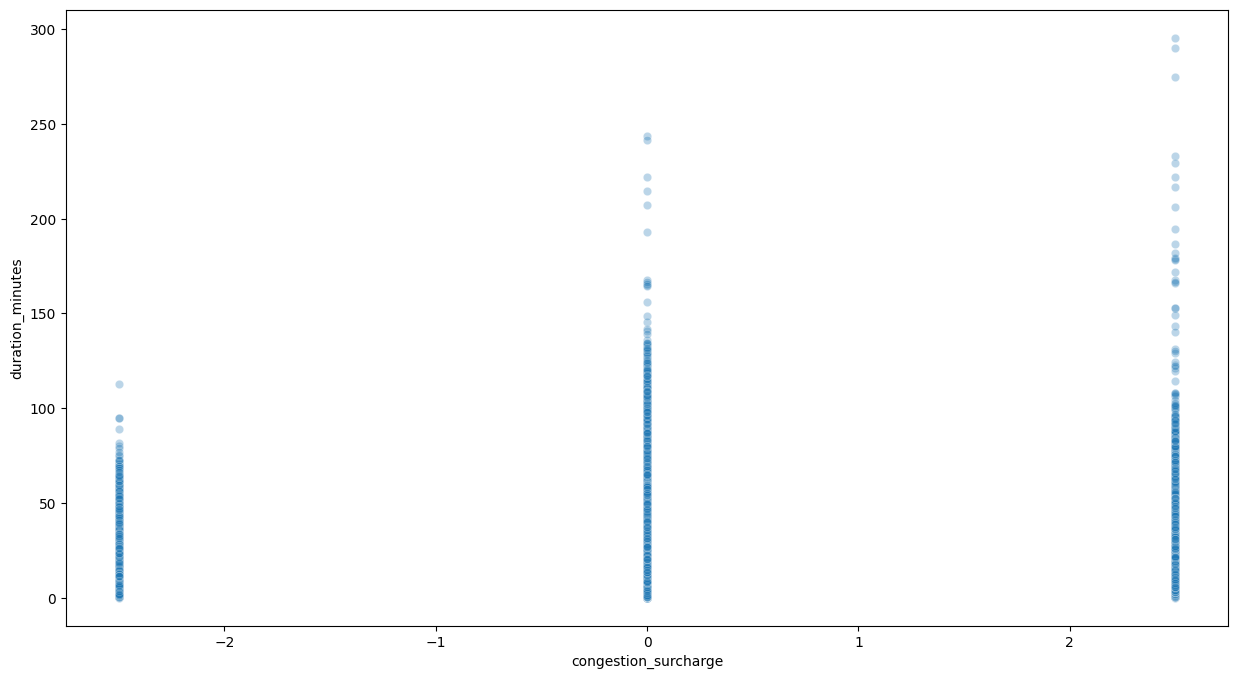

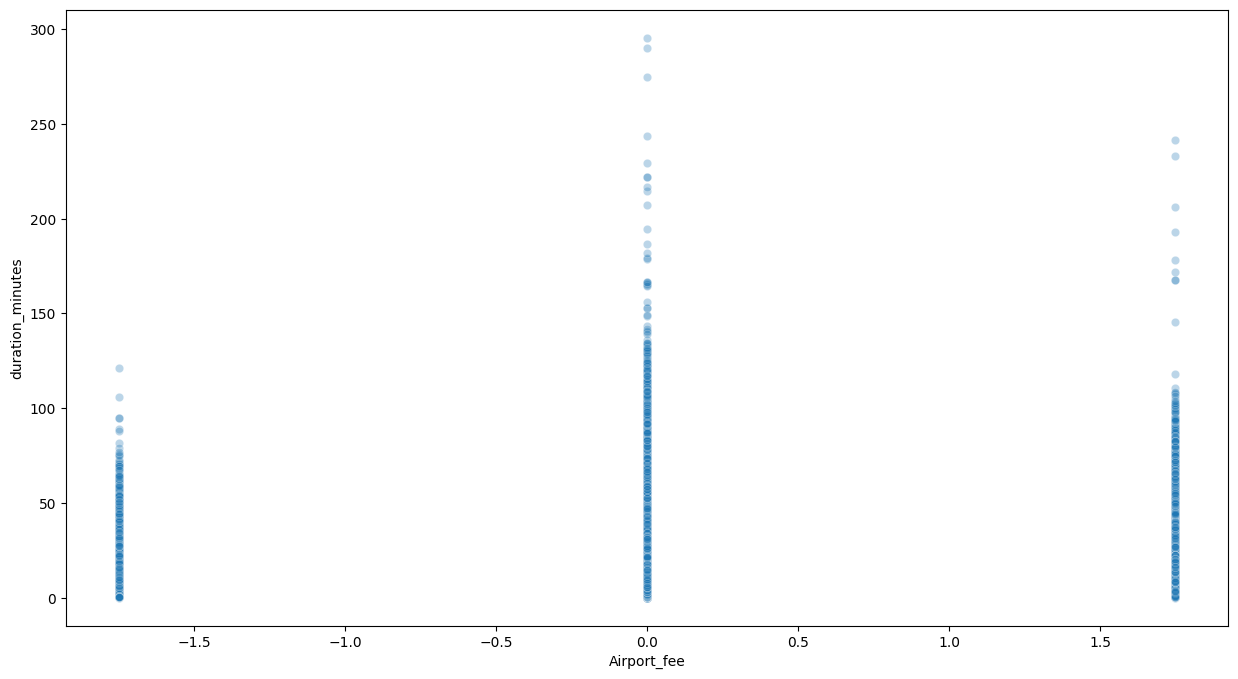

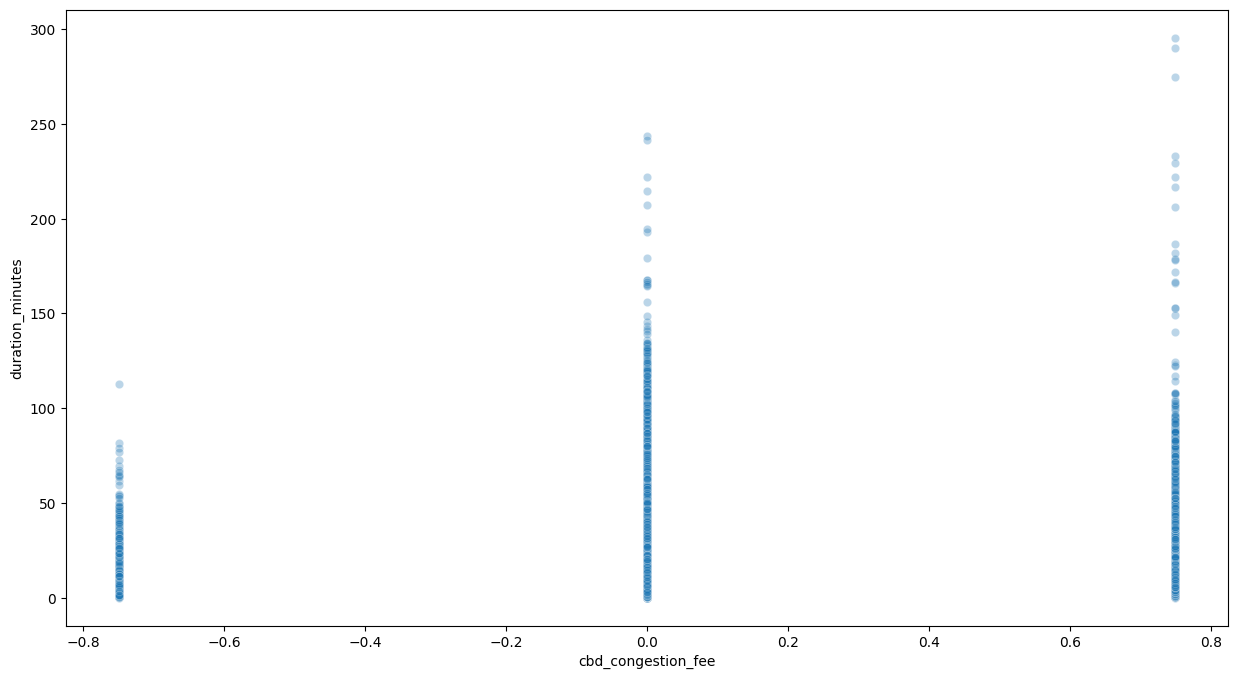

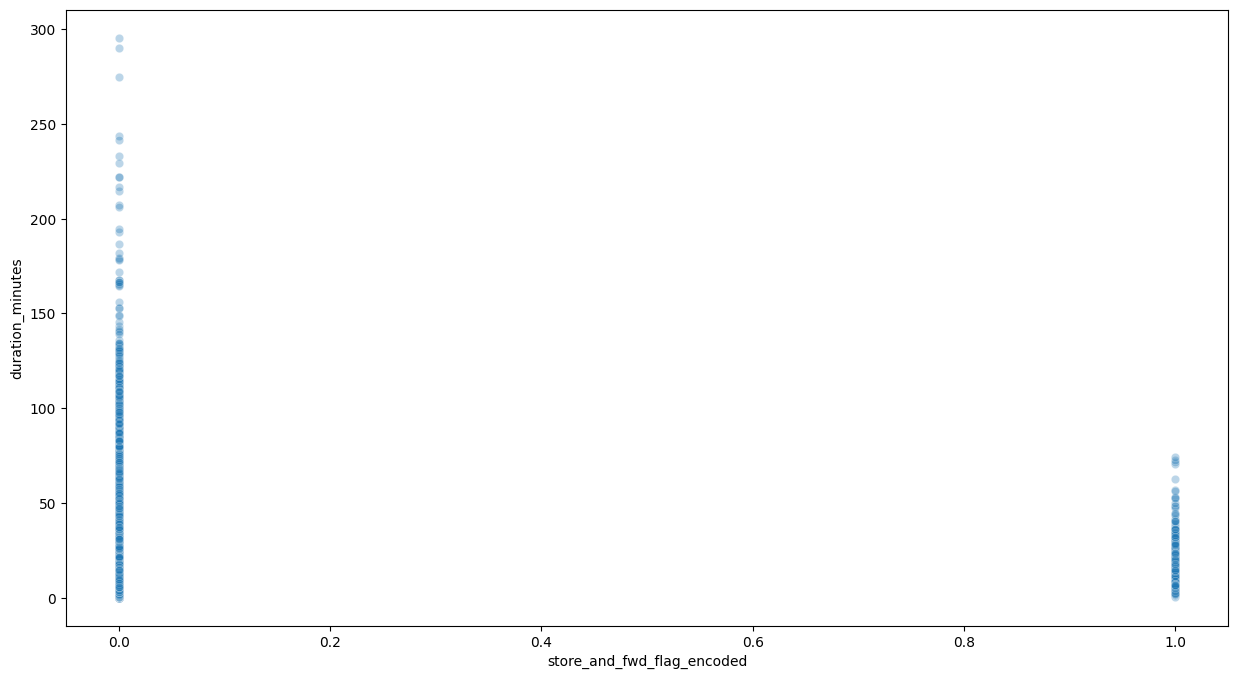

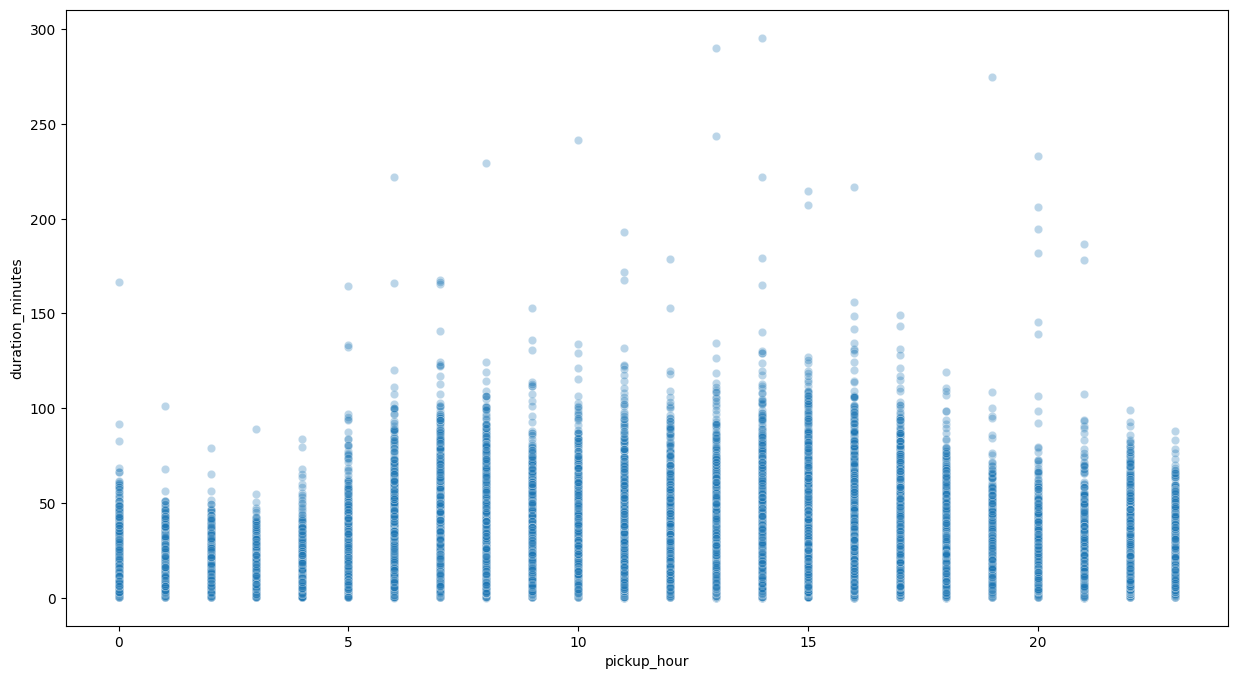

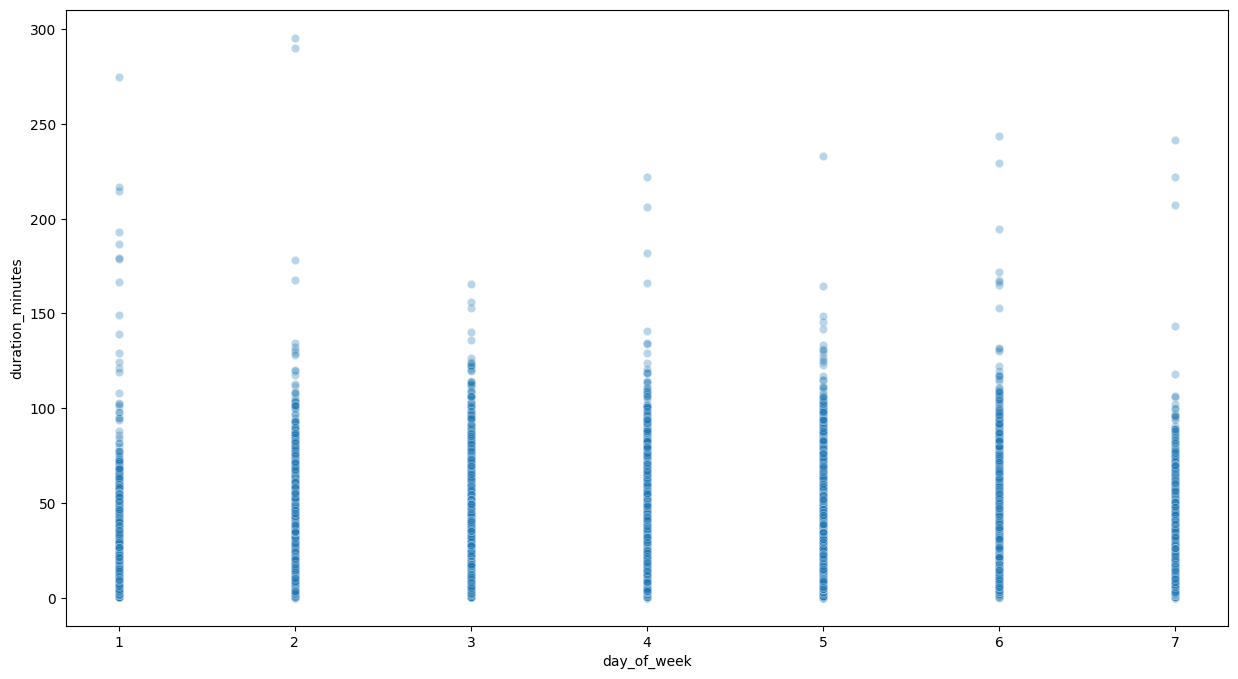

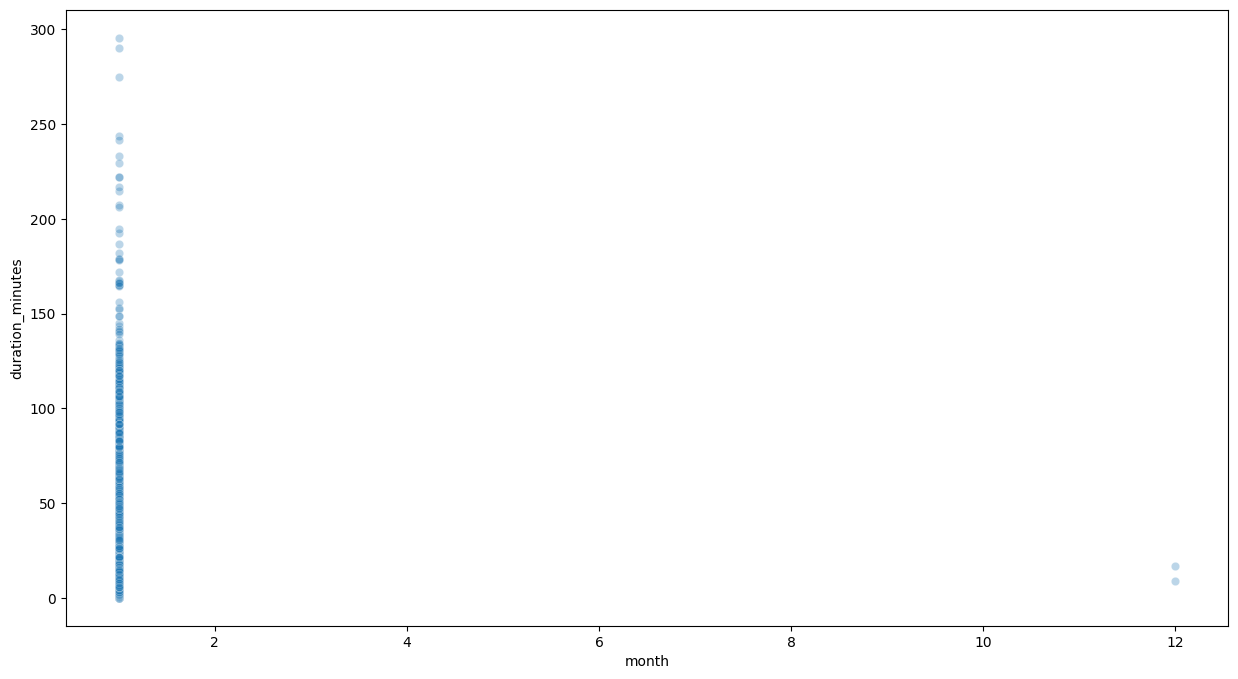

In [14]:
col_exception =["duration_seconds","duration_minutes"]
for col in pdf_sample:
    if col in col_exception:
        continue
    plt.figure(figsize=(15,8))
    sns.scatterplot(x=col, y='duration_minutes', data=pdf_sample, alpha=0.3)


### Trip Duration Distribution (Minutes)

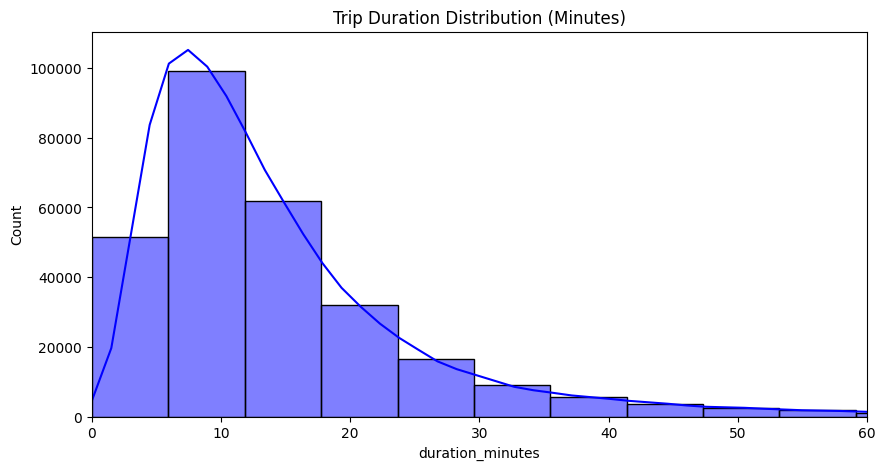

In [15]:
plt.figure(figsize=(10, 5))
sns.histplot(pdf_sample['duration_minutes'], bins=50, kde=True, color='blue')
# bins : 50 intervals/bars | kde : line shape | color : bars & KDE
plt.title("Trip Duration Distribution (Minutes)")
plt.xlim(0, 60)     # trips less than 1 hour
plt.show()

## save cleaned dataset

In [16]:
# output_path="../data/cleaned_data/silver_taxi.parquet"
# df_silver.write.parquet(output_path)


### append mode - silver dataset

In [17]:
# df_silver.write.mode("append").parquet(output_path)

In [18]:
df_encoded.show(5)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+----------------+-----------------+--------------------------+-----------+-----------+-----+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|duration_seconds| duration_minutes|store_and_fwd_flag_encoded|pickup_hour|day_of_week|month|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------

## Analyse SQL Avancée (Prototypage pour API)

In [19]:
# # Création d'une vue temporaire pour utiliser Spark SQL
# df_silver.createOrReplaceTempView("silver_taxi_trips")

# # Requête 1 : Analyse des paiements (Brief: /analytics/payment-analysis)
# query_payment = """
#     SELECT 
#         payment_type, 
#         COUNT(*) as total_trips, 
#         ROUND(AVG(duration_minutes), 2) as avg_duration 
#     FROM silver_taxi_trips 
#     GROUP BY payment_type 
#     ORDER BY total_trips DESC
# """

# spark.sql(query_payment).show()

# # Requête 2 : Analyse horaire (Brief: /analytics/avg-duration-by-hour)
# query_hourly = """
#     SELECT 
#         pickup_hour, 
#         ROUND(AVG(duration_minutes), 2) as avg_duration 
#     FROM silver_taxi_trips 
#     GROUP BY pickup_hour 
#     ORDER BY pickup_hour ASC
# """
# spark.sql(query_hourly).show(5)

## Training Process
### 1 - VectorAssembler (Funnel)

In [20]:
df_encoded.columns

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'Airport_fee',
 'cbd_congestion_fee',
 'duration_seconds',
 'duration_minutes',
 'store_and_fwd_flag_encoded',
 'pickup_hour',
 'day_of_week',
 'month']

In [21]:
from pyspark.ml.feature import VectorAssembler


feature_col=['VendorID',

 'passenger_count',
 'trip_distance',
 'RatecodeID',
 
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'Airport_fee',
 'cbd_congestion_fee',

 'store_and_fwd_flag_encoded',
 'pickup_hour',
 'day_of_week',
 'month']
# -> assembler (number list)
assembler=VectorAssembler(inputCols=feature_col, outputCol="features")

# -> ready for training
df_ready=assembler.transform(df_encoded)
df_ready.select("features", "duration_minutes")



DataFrame[features: vector, duration_minutes: double]

### 2- split

In [22]:
train_data, test_data=df_ready.randomSplit([0.8, 0.2], seed=42)
print(f"train data rows : {train_data.count()}")
print(f"test data rows : {test_data.count()}")

train data rows : 2295474


test data rows : 574606


In [23]:
if 'train_data' in locals():
    print(f"Variable found! Row count: {train_data.count()}")
else:
    print("Variable NOT found. You must run the split cell again.")

Variable found! Row count: 2295474


### 3- training 

In [24]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# --- Train
lr=LinearRegression(featuresCol="features", labelCol="duration_minutes")
lr_model=lr.fit(train_data)
print("_____ Model Trained Successfully! _____")

# --- Evaluate
print("_____ Evaluating on test data _____")
predictions=lr_model.transform(test_data)

# -> definition
evaluator_rmse=RegressionEvaluator(labelCol="duration_minutes",predictionCol="prediction",metricName="rmse")
evaluator_mae=RegressionEvaluator(labelCol="duration_minutes",predictionCol="prediction",metricName="mae")
evaluator_r2=RegressionEvaluator(labelCol="duration_minutes", predictionCol="prediction", metricName="r2")

# -> calculate
rmse=evaluator_rmse.evaluate(predictions)
mae=evaluator_mae.evaluate(predictions)
r2=evaluator_r2.evaluate(predictions)

print("________________________________________________")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} minutes")
print("________________________________________________")
print("________________________________________________")
print(f"Mean Absolute Error (MAE): {mae:.2f} minutes")
print("________________________________________________")
print("________________________________________________")
print(f"R² Score (Goodness of Fit): {r2:.2f}")
print("________________________________________________")


26/01/19 01:38:15 WARN Instrumentation: [8bb3748b] regParam is zero, which might cause numerical instability and overfitting.
26/01/19 01:38:26 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/01/19 01:38:29 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


_____ Model Trained Successfully! _____
_____ Evaluating on test data _____


________________________________________________
Root Mean Squared Error (RMSE): 6.41 minutes
________________________________________________
________________________________________________
Mean Absolute Error (MAE): 4.23 minutes
________________________________________________
________________________________________________
R² Score (Goodness of Fit): 0.71
________________________________________________


In [25]:
from pyspark.sql.functions import avg

# Calculate average trip duration
avg_duration = df_silver.select(avg("duration_minutes")).first()[0]

print(f"Average Trip Duration: {avg_duration:.2f} minutes")

Average Trip Duration: 15.02 minutes


## save the trained model

In [26]:
# # path
# model_path = "../models/taxi_lr_model"

# # Save action
# lr_model.write().overwrite().save(model_path)

# print(f"Model saved successfully at: {model_path}")

## readiest model

In [27]:
# from pyspark.ml.regression import LinearRegressionModel

# # Load the saved model
# loaded_model = LinearRegressionModel.load(model_path)

# print("Model loaded!")
# #-> loaded_model.transform(new_data) 

In [28]:
# Check the specific memory setting
# The second argument is what prints if you never changed it
memory = my_spark.conf.get("spark.driver.memory", "Default (Usually 1GB)")

print(f"Current Memory Assigned: {memory}")

Current Memory Assigned: 4g


In [29]:
from pyspark.sql import SparkSession

# Stop the old session first
my_spark.stop()

# Start a new session with 4GB of RAM
spark = SparkSession.builder \
    .appName("TaxiDurationPrediction") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .getOrCreate()

print("Spark Session restarted with 4GB RAM!")

Spark Session restarted with 4GB RAM!


In [30]:
from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(featuresCol="features", labelCol="duration_minutes", numTrees=10, maxDepth=5)

# Train
rf_model = rf.fit(train_data)

26/01/19 01:39:02 ERROR Instrumentation: java.lang.NullPointerException: Cannot invoke "org.apache.spark.sql.classic.SparkSession.sparkContext()" because the return value of "org.apache.spark.sql.execution.SparkPlan.session()" is null
	at org.apache.spark.sql.execution.SparkPlan.sparkContext(SparkPlan.scala:68)
	at org.apache.spark.sql.execution.WholeStageCodegenExec.metrics$lzycompute(WholeStageCodegenExec.scala:649)
	at org.apache.spark.sql.execution.WholeStageCodegenExec.metrics(WholeStageCodegenExec.scala:648)
	at org.apache.spark.sql.execution.SparkPlan.resetMetrics(SparkPlan.scala:147)
	at org.apache.spark.sql.execution.SparkPlan.$anonfun$resetMetrics$2(SparkPlan.scala:148)
	at org.apache.spark.sql.execution.SparkPlan.$anonfun$resetMetrics$2$adapted(SparkPlan.scala:148)
	at scala.collection.immutable.Vector.foreach(Vector.scala:2125)
	at org.apache.spark.sql.execution.SparkPlan.resetMetrics(SparkPlan.scala:148)
	at org.apache.spark.sql.execution.SparkPlan.$anonfun$resetMetrics$2(

Py4JJavaError: An error occurred while calling o447.fit.
: java.lang.NullPointerException: Cannot invoke "org.apache.spark.sql.classic.SparkSession.sparkContext()" because the return value of "org.apache.spark.sql.execution.SparkPlan.session()" is null
	at org.apache.spark.sql.execution.SparkPlan.sparkContext(SparkPlan.scala:68)
	at org.apache.spark.sql.execution.WholeStageCodegenExec.metrics$lzycompute(WholeStageCodegenExec.scala:649)
	at org.apache.spark.sql.execution.WholeStageCodegenExec.metrics(WholeStageCodegenExec.scala:648)
	at org.apache.spark.sql.execution.SparkPlan.resetMetrics(SparkPlan.scala:147)
	at org.apache.spark.sql.execution.SparkPlan.$anonfun$resetMetrics$2(SparkPlan.scala:148)
	at org.apache.spark.sql.execution.SparkPlan.$anonfun$resetMetrics$2$adapted(SparkPlan.scala:148)
	at scala.collection.immutable.Vector.foreach(Vector.scala:2125)
	at org.apache.spark.sql.execution.SparkPlan.resetMetrics(SparkPlan.scala:148)
	at org.apache.spark.sql.execution.SparkPlan.$anonf

## Sérialisation (Test de sauvegarde)

In [ ]:

# # Test de sauvegarde pour vérifier que ça fonctionnera dans le script final
# model_path = "models/model_notebook_test.pkl"
# os.makedirs("models", exist_ok=True)

# joblib.dump(rf_model, model_path)
# print(f"Modèle sauvegardé avec succès sous : {model_path}")

# # Test de rechargement
# loaded_model = joblib.load(model_path)
# test_pred = loaded_model.predict(X_test.iloc[0:1])
# print(f"Test prédiction (1 ligne) : {test_pred[0]:.2f} minutes")

NameError: name 'os' is not defined

## Arrêt de Spark

In [ ]:
# spark.stop()

In [31]:
# import pandas as pd
# import io

# # Configuration
# FILE_NAME = "data/bronze_taxi.parquet"
# OUTPUT_FILE = "context_pour_ai_studio.txt"

# def generate_report():
#     try:
#         df = pd.read_parquet(FILE_NAME)
        
#         # Buffer pour écrire le rapport
#         buffer = io.StringIO()
        
#         buffer.write(f"--- RAPPORT CONTEXTUEL DE DONNÉES : {FILE_NAME} ---\n")
#         buffer.write("Ce rapport décrit la structure et la distribution des données pour un projet Data Engineering.\n\n")
        
#         # 1. MÉTADONNÉES GÉNÉRALES
#         buffer.write(f"## 1. VOLUMÉTRIE\n")
#         buffer.write(f"- Nombre de lignes : {len(df)}\n")
#         buffer.write(f"- Nombre de colonnes : {len(df.columns)}\n")
#         buffer.write(f"- Usage Mémoire (approx) : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB\n\n")
        
#         # 2. ANALYSE DÉTAILLÉE PAR COLONNE
#         buffer.write("## 2. DÉTAILS DES VARIABLES ET DISTRIBUTIONS\n")
        
#         for col in df.columns:
#             dtype = df[col].dtype
#             buffer.write(f"\n### Variable: '{col}' (Type: {dtype})\n")
            
#             # Gestion des valeurs manquantes
#             nulls = df[col].isnull().sum()
#             if nulls > 0:
#                 buffer.write(f"- Valeurs manquantes : {nulls} ({nulls/len(df):.2%})\n")
            
#             # Analyse Spécifique selon le type
#             if pd.api.types.is_numeric_dtype(dtype):
#                 stats = df[col].describe()
#                 buffer.write(f"- Stats : Min={stats['min']}, Max={stats['max']}, Moyenne={stats['mean']:.2f}\n")
                
#                 # Détection de potentielles anomalies (valeurs négatives pour des montants)
#                 negatives = (df[col] < 0).sum()
#                 if negatives > 0 and "amount" in col:
#                     buffer.write(f"- NOTE : Contient {negatives} valeurs négatives (potentiels retours/erreurs).\n")
                    
#             elif pd.api.types.is_datetime64_any_dtype(dtype):
#                 buffer.write(f"- Période temporelle : De {df[col].min()} à {df[col].max()}\n")
                
#             else: # Objets / Catégories / IDs
#                 unique_count = df[col].nunique()
#                 buffer.write(f"- Cardinalité : {unique_count} valeurs uniques\n")
#                 if unique_count < 50:
#                     top_vals = df[col].value_counts().head(5).to_dict()
#                     buffer.write(f"- Top valeurs fréquentes : {top_vals}\n")
        
#         # 3. ÉCHANTILLON DE DONNÉES
#         buffer.write("\n## 3. ÉCHANTILLON BRUT (JSON)\n")
#         buffer.write("Voici 3 lignes représentatives pour comprendre le format exact :\n")
#         buffer.write(df.head(3).to_json(orient='records', date_format='iso', lines=True))
        
#         # Sauvegarde
#         with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
#             f.write(buffer.getvalue())
            
#         print(f"✅ Succès ! Le rapport a été généré dans '{OUTPUT_FILE}'.")

#     except Exception as e:
#         print(f"❌ Erreur : {e}")

# if __name__ == "__main__":
#     generate_report()